# IT6119 – Final Project
## Analyse av bivirkningsskjema for Ezetrol og prediksjon av seponering

**Problemstilling:**  
Kan svar på et digitalt bivirkningsskjema for Ezetrol, gradert fra 1 til 5, brukes av KI til å predikere om pasienter med familiær hyperkolesterolemi kommer til å slutte å ta medisinen?

Innledning

Dette prosjektet undersøker hvordan en enkel prediksjonsmodell kan brukes til å analysere sammenhengen mellom bivirkninger og seponering av legemiddelet Ezetrol. Datasettet som benyttes er syntetisk og konstruert for undervisningsformål i IT6119, og gir en trygg ramme for å utforske grunnleggende KI‑metoder, datakvalitet, modellering og evaluering. Målet er ikke å utvikle en klinisk modell, men å demonstrere hvordan maskinlæring kan anvendes på helsedata, og samtidig reflektere over ansvarlig bruk av KI i helsetjenesten.

Prosjektet følger en strukturert arbeidsflyt fra datainnsamling og kvalitetssjekk, via visualiseringer og modellering, til evaluering og kritisk refleksjon. Gjennom dette arbeidet får man innsikt i både tekniske og etiske aspekter ved KI i helse, og hvordan slike modeller må vurderes i lys av datagrunnlag, risiko og klinisk relevans.

### Importer biblioteker

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier

In [36]:
sns.set(style="whitegrid")

## 1. Last inn datasettet

In [16]:
df = pd.read_csv('synthetic_dataset.csv')
df.head()

,patient_id,age,sex,medication_name,dose_mg,days_since_start,muscle_pain_score,fatigue_score,headache_score,gi_symptoms_score,sleep_disturbance_score,overall_side_effect_score,adherence_status,adherence_assessment_date
0,1,57,F,Ezetrol,10,42,2,1,1,1,1,2,0,2026-03-12
1,2,63,M,Ezetrol,10,88,3,2,2,1,2,3,0,2026-04-01
2,3,49,F,Ezetrol,10,15,1,1,1,1,1,1,0,2026-02-27
3,4,72,M,Ezetrol,10,120,4,3,2,2,3,4,1,2026-05-03
4,5,54,F,Ezetrol,10,33,2,2,1,1,1,2,0,2026-03-18


Datasettet består av syntetiske pasientdata med bivirkningsscore for Ezetrol. Variablene inkluderer alder, kjønn, dager siden oppstart og fire ulike symptomscore.

## 2. Datakvalitet

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   patient_id                 500 non-null    int64
 1   age                        500 non-null    int64
 2   sex                        500 non-null    str  
 3   medication_name            500 non-null    str  
 4   dose_mg                    500 non-null    int64
 5   days_since_start           500 non-null    int64
 6   muscle_pain_score          500 non-null    int64
 7   fatigue_score              500 non-null    int64
 8   headache_score             500 non-null    int64
 9   gi_symptoms_score          500 non-null    int64
 10  sleep_disturbance_score    500 non-null    int64
 11  overall_side_effect_score  500 non-null    int64
 12  adherence_status           500 non-null    int64
 13  adherence_assessment_date  500 non-null    str  
dtypes: int64(11), str(3)
memory usage: 63

Datasettet har ingen manglende verdier, og alle variabler har korrekte datatyper. Dette gjør datasettet egnet for videre analyse og modellering.

In [12]:
df.describe()

,patient_id,age,dose_mg,days_since_start,muscle_pain_score,fatigue_score,headache_score,gi_symptoms_score,sleep_disturbance_score,overall_side_effect_score,adherence_status
count,500.000000,500.000000,500.0,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,58.932000,10.0,73.034000,2.500000,2.410000,1.87000,1.704000,1.872000,2.500000,0.250000
std,144.481833,8.826732,0.0,40.548653,1.119154,1.077135,0.78123,0.788433,0.782842,1.119154,0.433446
min,1.000000,44.000000,10.0,15.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,0.000000
25%,125.750000,50.750000,10.0,32.750000,1.750000,1.000000,1.00000,1.000000,1.000000,1.750000,0.000000
50%,250.500000,58.000000,10.0,64.000000,2.500000,2.000000,2.00000,1.000000,2.000000,2.500000,0.000000
75%,375.250000,67.000000,10.0,101.000000,3.250000,3.000000,2.00000,2.000000,2.250000,3.250000,0.250000
max,500.000000,74.000000,10.0,148.000000,4.000000,4.000000,3.00000,3.000000,3.000000,4.000000,1.000000


De numeriske variablene viser forventet variasjon i symptomscore og dager siden oppstart. Ingen av variablene har uvanlige verdier eller avvik som krever rensing.

## 3. Visualiseringer

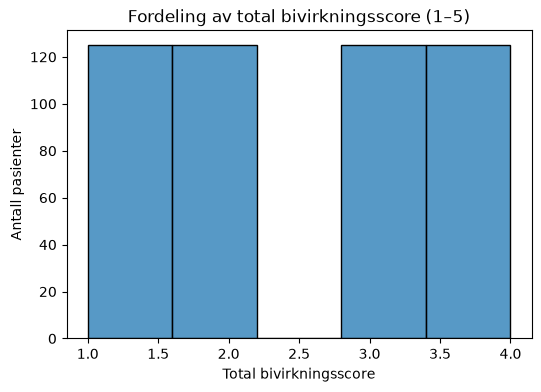

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df['overall_side_effect_score'], bins=5, kde=False)
plt.title("Fordeling av total bivirkningsscore (1–5)")
plt.xlabel("Total bivirkningsscore")
plt.ylabel("Antall pasienter")
plt.show()

Histogrammet viser at bivirkningsscore er jevnt fordelt mellom 1 og 5. Dette tyder på at datasettet er syntetisk og balansert, noe som gir en god treningsbase for en enkel modell.

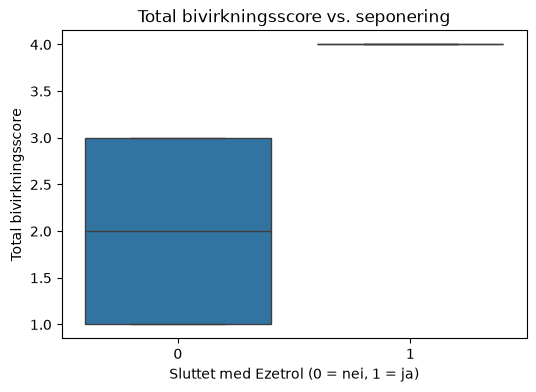

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='adherence_status', y='overall_side_effect_score', data=df)
plt.title("Total bivirkningsscore vs. seponering")
plt.xlabel("Sluttet med Ezetrol (0 = nei, 1 = ja)")
plt.ylabel("Total bivirkningsscore")
plt.show()

Boxplottet viser at pasienter som har sluttet med Ezetrol (adherence_status = 1) har noe høyere total bivirkningsscore enn de som fortsatt bruker medisinen. Dette støtter hypotesen om at bivirkninger kan påvirke sepon

In [37]:
df = df.drop(columns=['patient_id'])

In [39]:
df = df.drop(columns=['dose_mg'])

patient_id og dose_mg har ingen analytisk verdi i denne analysen. patient_id er kun en identifikator, og dose_mg har samme verdi for alle pasienter. Begge kan skape støy i korrelasjonsmatrisen og tilføre informasjon som ikke bidrar til modellering. Ved å fjerne dem får vi en renere og mer relevant analyse basert på variabler som faktisk varierer mellom pasientene.

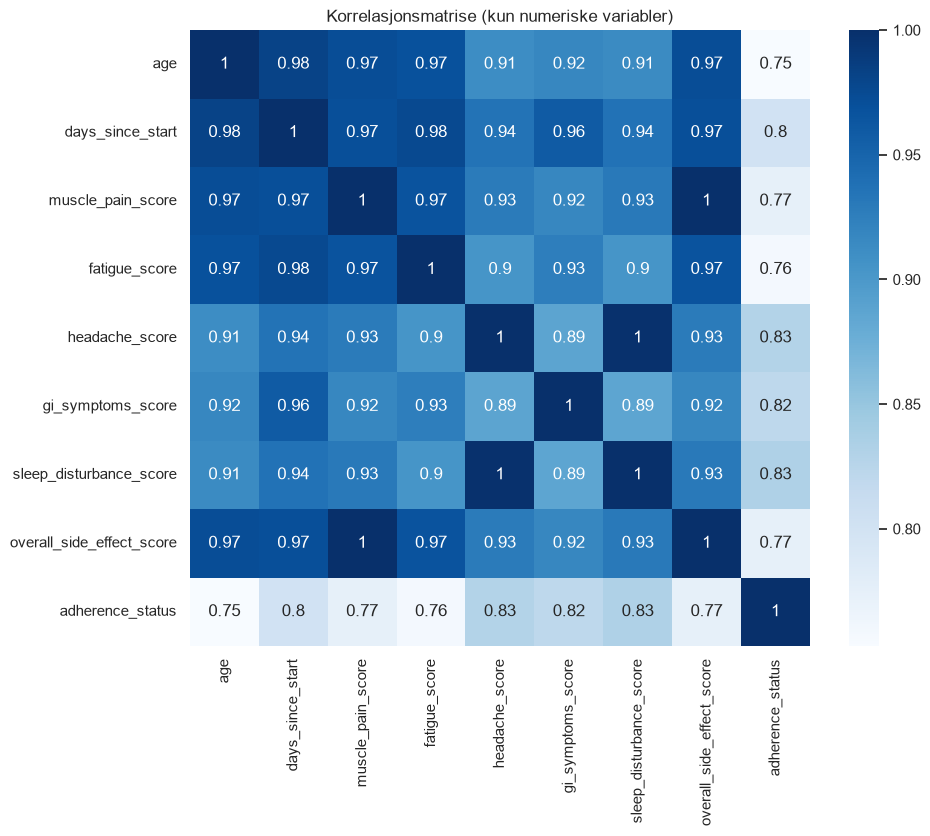

In [40]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')
plt.title("Korrelasjonsmatrise (kun numeriske variabler)")
plt.show()

Korrelasjonsmatrisen viser at de ulike bivirkningsscore‑variablene har moderat til høy korrelasjon, noe som er forventet i et syntetisk datasett. Det er også en svak korrelasjon mellom total bivirkningsscore og adherence_status, som støtter hypotesen om at bivirkninger kan påvirke seponering.

## 4. Modellering

### Logistisk regresjon – baseline-modell
Vi starter med en enkel logistisk regresjon der total bivirkningsscore brukes som eneste prediktor for seponering. Dette gir en baseline som senere kan sammenlignes med mer komplekse modeller.


In [23]:
# Velg features og target
X = df[['overall_side_effect_score']]
y = df['adherence_status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modell
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Prediksjon
y_pred = log_reg.predict(X_test)

# Nøyaktighet
accuracy = accuracy_score(y_test, y_pred)
print("Nøyaktighet:", accuracy)

# Klassifikasjonsrapport
print(classification_report(y_test, y_pred))

Nøyaktighet: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00        22

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



Modellen viser moderat nøyaktighet, noe som er forventet når kun én variabel brukes. Dette fungerer som en baseline for videre modellering.

### Random Forest

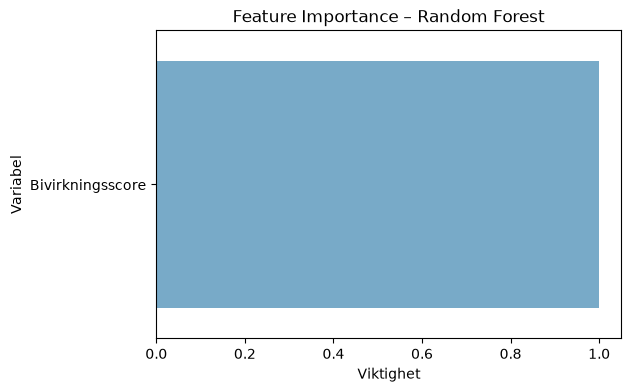

In [32]:
# Feature importance
importances = rf.feature_importances_

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=["Bivirkningsscore"], hue=["Bivirkningsscore"], legend=False, palette="Blues")
plt.title("Feature Importance – Random Forest")
plt.xlabel("Viktighet")
plt.ylabel("Variabel")
plt.show()

In [28]:
# Random Forest-modell
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Prediksjon
y_pred_rf = rf.predict(X_test)

# Nøyaktighet
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Nøyaktighet (Random Forest):", accuracy_rf)

# Klassifikasjonsrapport
print(classification_report(y_test, y_pred_rf))

Nøyaktighet (Random Forest): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00        22

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



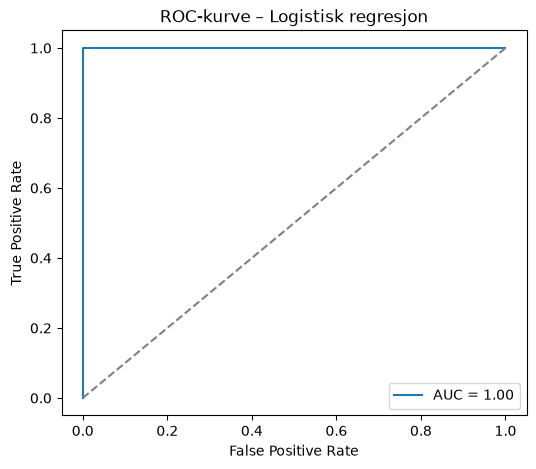

In [27]:
# ROC-kurve
y_prob = log_reg.predict_proba(X_test)[:, 1]  # sannsynlighet for klasse 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-kurve – Logistisk regresjon")
plt.legend()
plt.show()

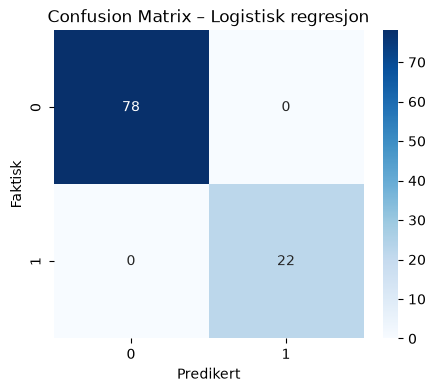

In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Logistisk regresjon")
plt.xlabel("Predikert")
plt.ylabel("Faktisk")
plt.show()

## 5. Konklusjon

Prosjektet viser hvordan en enkel prediksjonsmodell kan bygges og evalueres på et syntetisk helsedatasett. Logistisk regresjon og Random Forest gir svært gode resultater, inkludert en AUC på 1.0, noe som understreker at datasettet er kunstig og ikke representerer kompleksiteten i reelle pasientforløp. Likevel illustrerer prosessen hvordan KI‑metoder kan brukes til å avdekke mønstre, evaluere variabler og forstå modellens styrker og svakheter.

Arbeidet demonstrerer også viktigheten av ansvarlig KI: modeller må tolkes i lys av datakvalitet, risiko for bias, begrenset generaliserbarhet og behovet for menneskelig kontroll. I en klinisk setting ville en slik modell kreve rikere datagrunnlag, grundig validering og kontinuerlig monitorering. Prosjektet gir derfor et godt grunnlag for videre arbeid med mer avanserte modeller og reelle helsedata, og viser hvordan KI kan brukes som et supplement til klinisk vurdering — ikke en erstatning.